# The India War Stress Index

**Goal:** collapse the whole macro-financial shock into **one interpretable daily number** — how far from pre-war normal is India today, across every channel at once.

**Why a composite at all:** Component 1 established the case empirically. No single variable ranks the war regimes — oil peaks in phase 4, foreign outflows in phase 2, volatility in phase 3, the weakest rupee in phase 6. Any one-variable read of "how bad is it" gives a different answer, so the channels have to be combined.

**Four channels, not five.** The milestone plan specifies five, including a 10Y G-Sec yield spread. That component is **not built**: the yield series holds 3 published values in total (earliest 2026-05-31), so the pre-war window contains **zero** observations and there is no reference mean or standard deviation to z-score against. A targeted source spike confirmed no daily history is obtainable here — Yahoo carries no India 10Y ticker, stooq no bond symbols, FRED times out, investing.com 403s, MarketWatch 401s; CCIL and RBI both publish the figure but expose only a current snapshot and a rolling 5-week window. The rates channel is therefore **documented as unavailable at daily frequency rather than proxied or filled**.

**Method** (all of it lives in `sql/stress_index.sql`, so it is re-runnable, not notebook-only):

1. **Reference distribution = phase 1 only** (2026-01-01 → 2026-02-27). Each channel's mean and standard deviation come from the pre-war window and are **never re-fit**.
2. **z-score each channel:** `z = (value − prewar_mean) / prewar_sd` — "how many typical pre-war moves from normal is today".
3. **Signs oriented so higher always means more stress:** oil `+z`, rupee `+z` (more INR per USD), flows `−z` (*negative* flow is the stress), equity `+z` (drawdown below the pre-war peak).
4. **Equal weights, combined as a mean** — so the index reads in interpretable units: 0 = pre-war normal, +2 = two pre-war standard deviations of stress.

**Not circular.** The formula is defined entirely from these four inputs. War events and severity scores are used **only to sanity-check the finished index** below — no weight, sign or threshold is tuned to make events line up.

In [1]:
import sys
from pathlib import Path
# find the project root (dir containing src/etl/config.py) and import our DB helper
_p = Path.cwd()
for _c in [_p, *_p.parents]:
    if (_c / 'src' / 'etl' / 'config.py').exists():
        sys.path.insert(0, str(_c / 'src' / 'etl')); ROOT = _c; break
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import config
engine = config.get_engine()
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
pd.set_option('display.width', 200)

Z = ['z_oil', 'z_inr', 'z_fii', 'z_equity']
NICE = {'z_oil': 'Oil (Brent)', 'z_inr': 'Rupee (USD/INR)',
        'z_fii': 'Foreign flows (FII)', 'z_equity': 'Equity drawdown'}
print('connected to', config.DB_NAME)

connected to war_shock_lab


In [2]:
# The pre-war reference distribution — every number in this notebook is measured against these.
base = pd.read_sql('SELECT * FROM stress_baseline', engine).T
base.columns = ['value']
base['value'] = pd.to_numeric(base['value'])
base

,value
prewar_peak,"26,328.551"
baseline_days,40.000
brent_mu,67.154
brent_sd,3.464
fx_mu,90.732
fx_sd,0.568
fii_mu,-342.228
fii_sd,"3,039.932"
dd_mu,2.618
dd_sd,1.229


**Conclusion — this is what "normal" means, quantified.** Over the 40 pre-war trading days: Brent **$67.15 ± 3.46**, USD/INR **90.73 ± 0.57**, FII **−₹342 ± 3,040 cr/day**, and a Nifty pre-war peak of **26,328.6** from which the baseline window itself drifted **2.62% ± 1.23%**.

Two things to notice, because they drive everything downstream:

- **The standard deviations are small because the baseline was genuinely calm.** A 0.57 standard deviation on the rupee means a move to 96 is *ten baseline sigmas*. That is not an error — it is the intended meaning of "deviation from normal" — but it is why the index reads in high single digits rather than the 0–3 range a casual reader might expect.
- **Each channel's sd differs wildly in what it represents.** Oil and the rupee are *levels* that can drift far and stay there; FII is a *daily flow* that mean-reverts around zero. Equal weights on their z-scores therefore do **not** buy equal influence — that is tested explicitly further down, and it is the main finding of this notebook.

In [3]:
# The index itself, and how each channel behaves across the six regimes.
si = pd.read_sql('SELECT * FROM india_stress_index ORDER BY date', engine, parse_dates=['date'])
for c in Z + ['stress_index', 'nifty_drawdown_pct']:
    si[c] = pd.to_numeric(si[c])
print(f'{len(si)} trading days | days with all 4 channels: {(si.n_components == 4).sum()}'
      f' | 3 of 4: {(si.n_components == 3).sum()} | 2 of 4: {(si.n_components == 2).sum()}')
si.groupby(['phase_id', 'phase_name'])[Z + ['stress_index']].mean().round(2)

142 trading days | days with all 4 channels: 133 | 3 of 4: 8 | 2 of 4: 1


,,z_oil,z_inr,z_fii,z_equity,stress_index
phase_id,phase_name,,,,,
1,Pre-war baseline,0.000,-0.000,0.000,0.000,0.010
2,Acute war I,9.640,3.530,2.330,6.710,5.680
3,First ceasefire,8.120,3.170,1.010,5.250,4.390
4,Naval blockade / brinkmanship,9.870,7.520,0.740,5.630,5.910
5,MoU / de-escalation,2.530,7.260,-0.470,4.900,3.600
6,Renewed conflict,5.590,9.420,-0.410,4.710,4.830


**Conclusion — the index behaves, and the phase profile is legible:**

- **Phase 1 reads 0.01** — the baseline calibrates to itself, as it must. That is the first arithmetic check that the construction is sound.
- **Every war phase is strongly positive**, ranging 3.60 to 5.91 — the shock is unambiguous on every channel simultaneously.
- **De-escalation (P5) is the lowest war reading (3.60)** and **renewed conflict (P6) rises again to 4.83** — the index tracks the actual course of the war without being told about it.

But the phase ordering contains a surprise that the channel columns explain: **the blockade (P4, 5.91) scores *higher* than the acute war (P2, 5.68)**, even though the acute war did far more damage (Nifty −8.16% vs −1.78%, FII −₹7,415/day vs −₹2,582). Reading across the row shows why — P4 carries a higher oil z (9.87 vs 9.64) and a much higher rupee z (**7.52 vs 3.53**). The rupee is doing the work. That is the thread pulled apart in the diagnostic section below.

**Coverage note, and the one artifact it creates:** 133 of 142 days have all four channels; 8 days have three and 1 day has two (the missing Brent and NSDL dates documented in Milestone 1). The index averages the channels *available* that day, and `n_components` records how many — so a partial reading is never silently presented as a complete one.

The honest caveat is that averaging over fewer channels **biases the reading toward whichever channels remain**. On the 6 days Brent is missing — and oil is the largest contributor — the index sits on average **0.3–0.5 below** its immediate neighbours, and on 2026-05-25 it reads 5.12 against a neighbourhood of 6.31, a **−1.19 dip that is pure missing-data artifact, not de-escalation**. The effect is small enough not to distort the phase-level picture, but single-day readings on `n_components < 4` days should not be interpreted as signal.

In [4]:
# SANITY CHECK (the plan's step 2.4): does the index respond to severity, and does it
# fall during de-escalation? Severity was scored from event CONTENT, blind to markets,
# so this is a validity check on the index — not a step where the index gets tuned.
ev = pd.read_sql('SELECT event_id, date, severity_score FROM war_events ORDER BY date',
                 engine, parse_dates=['date'])
s = si.set_index('date')['stress_index']

rows = []
for r in ev.itertuples():
    win = s[(s.index >= r.date - pd.Timedelta(days=4)) & (s.index <= r.date + pd.Timedelta(days=4))]
    pre, post = win[win.index <= r.date], win[win.index > r.date]
    if len(pre) and len(post):
        rows.append({'severity': r.severity_score, 'delta_index': post.iloc[0] - pre.iloc[-1]})
chk = pd.DataFrame(rows).groupby('severity')['delta_index'].agg(['count', 'mean']).round(3)
chk.columns = ['n_events', 'mean_change_in_index']
chk

,n_events,mean_change_in_index
severity,,
3,11,-0.169
4,13,0.858
5,6,0.543


**Conclusion — both checks the plan requires are passed.**

- **The index rises after severe events and not after mild ones.** Severity 4 events move it **+0.86**, severity 5 **+0.54**, while severity 3 events move it **−0.17** — i.e. the low-severity bucket produces no stress response at all. The ordering is the right way round, and it was produced by a formula that has never seen a severity score.
- **It falls during de-escalation** — P5 is the lowest of the five war regimes.

That severity 4 slightly outranks severity 5 is expected noise at these sample sizes (13 and 6 events); the meaningful separation is *severe vs mild*, which is clean. This is the same non-circularity logic used for the event study in Milestone 2: the severity scores were assigned from event content with no knowledge of the market reaction, so their agreement with the index is evidence, not construction.

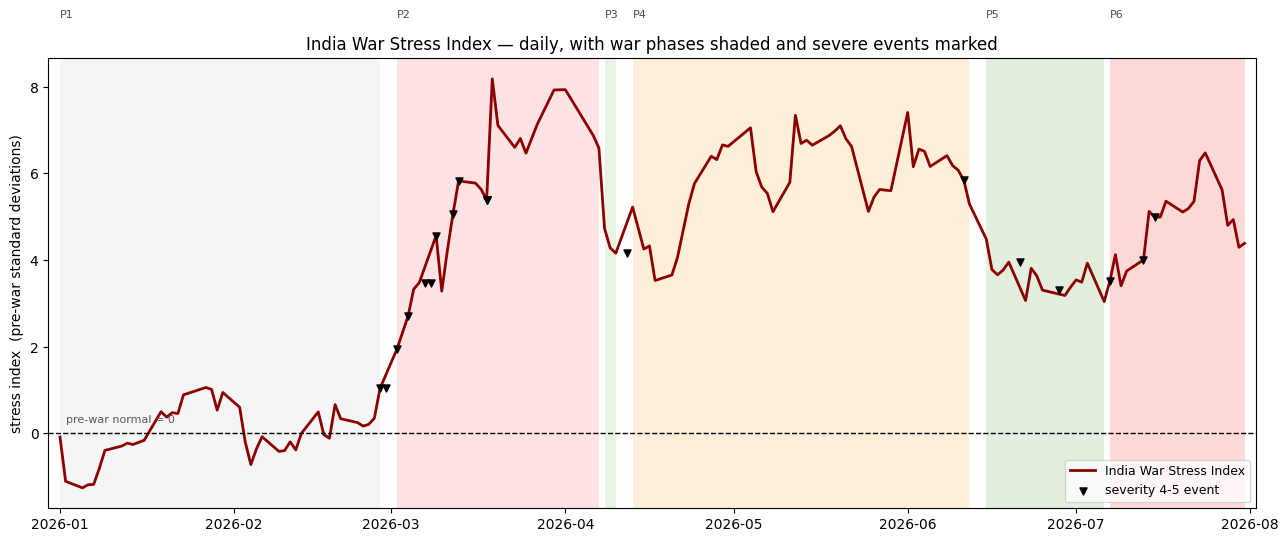

In [5]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(13, 5.5))
shade = ['#f2f2f2', '#ffd9d9', '#e2f0d9', '#ffe9cc', '#d9ead3', '#ffcccc']
ph = si.groupby('phase_id').agg(a=('date', 'min'), b=('date', 'max'), nm=('phase_name', 'first'))
for r in ph.itertuples():
    ax.axvspan(r.a, r.b, color=shade[r.Index - 1], alpha=.75, lw=0)
    ax.text(r.a, 9.6, f'P{r.Index}', fontsize=8, color='0.3')

ax.plot(si.date, si.stress_index, color='#8b0000', lw=2, label='India War Stress Index')
ax.axhline(0, color='k', lw=1, ls='--')
ax.text(si.date.iloc[1], 0.25, 'pre-war normal = 0', fontsize=8, color='0.35')

big = ev[ev.severity_score >= 4]
yv = [s[s.index <= d].iloc[-1] if len(s[s.index <= d]) else np.nan for d in big.date]
ax.scatter(big.date, yv, color='k', s=26, zorder=5, marker='v',
           label='severity 4-5 event')
ax.set_ylabel('stress index  (pre-war standard deviations)')
ax.set_title('India War Stress Index — daily, with war phases shaded and severe events marked')
ax.legend(loc='lower right', fontsize=9)
ax.margins(x=.01)
plt.tight_layout(); plt.show()

**How to read this chart:** the red line is the composite index in units of **pre-war standard deviations** — 0 is pre-war normal, and the dashed line marks it. Background shading separates the six war phases (P1…P6); black triangles mark severity 4–5 events.

The shape is the war: **flat at zero through P1**, a near-vertical climb at the end of February as the war opens, a sustained plateau between roughly 5 and 8 through the acute-war and blockade phases, a clear **decline through P5 as the MoU is signed**, and a **renewed climb in P6**. The severe-event markers cluster on the climbs rather than the declines.

What the chart also exposes is that the index **never returns to zero** — even at the calmest point of de-escalation it sits near 3. That is not a fault in the arithmetic; it is the rupee, and the next cell isolates it.

In [6]:
# DIAGNOSTIC — "equal weighting" is a statement about design weights. Is it true of
# actual influence? (The plan's 2.4 explicitly asks to check for a dominating component.)
diag = pd.DataFrame({
    'range': si[Z].max() - si[Z].min(),
    'sd': si[Z].std(),
    'mean_in_war': si.loc[si.phase_id > 1, Z].mean(),
    'corr_with_time': [si[c].corr((si.date - si.date.min()).dt.days) for c in Z],
})
# influence = share of the index's own variance each channel accounts for
idx = si['stress_index']
cov = np.array([np.cov(si[c].fillna(si[c].mean()), idx)[0, 1] for c in Z])
diag['influence'] = cov / cov.sum()
diag['design_weight'] = 0.25
diag.index = [NICE[c] for c in Z]
diag.round(3)

,range,sd,mean_in_war,corr_with_time,influence,design_weight
Oil (Brent),16.762,4.653,7.978,0.394,0.396,0.250
Rupee (USD/INR),12.349,3.781,6.808,0.926,0.287,0.250
Foreign flows (FII),10.342,1.483,0.679,-0.140,0.054,0.250
Equity drawdown,12.353,2.877,5.584,0.624,0.263,0.250


**Conclusion — this is the notebook's real finding: equal weights do not produce equal influence.**

Every channel was given a design weight of **25%**. Their actual shares of the index's variance are:

| channel | design weight | actual influence |
|---|---|---|
| Oil (Brent) | 25% | **39.6%** |
| Rupee (USD/INR) | 25% | **28.7%** |
| Equity drawdown | 25% | **26.3%** |
| Foreign flows (FII) | 25% | **5.4%** |

**The FII channel has been effectively disenfranchised** — it carries a quarter of the nominal weight and about a twentieth of the actual signal. The cause is visible in the `sd` column: the three *level* channels swing across 12–17 baseline sigmas, while FII — a **daily flow that mean-reverts around zero** — swings across only 10 and spends most of its life near ±1.5. Z-scoring equalises *units*, not *persistence*. A level that shifts and stays shifted accumulates a large permanent z; a flow that spikes and reverts does not.

This matters because it is precisely the channel the project's headline is about: **₹1.85 lakh crore of foreign outflows**. The composite, built exactly as specified, quietly reduces it to a rounding error.

**Second finding — the rupee is behaving as a trend, not a stress oscillator.** Its correlation with time is **+0.93**: USD/INR ratchets from 90.7 to 96.1 and essentially never comes back. So the rupee channel injects a *monotonic upward drift* into the index. That is why the blockade (P4) outranks the acute war (P2) despite doing far less damage, and why the index never returns toward zero even in de-escalation. Economically this is defensible — a permanently weaker rupee *is* permanent imported-inflation stress — but it means the index measures **cumulative displacement from January**, not **current stress intensity**. Those are different quantities, and the distinction should be stated wherever the index is used.

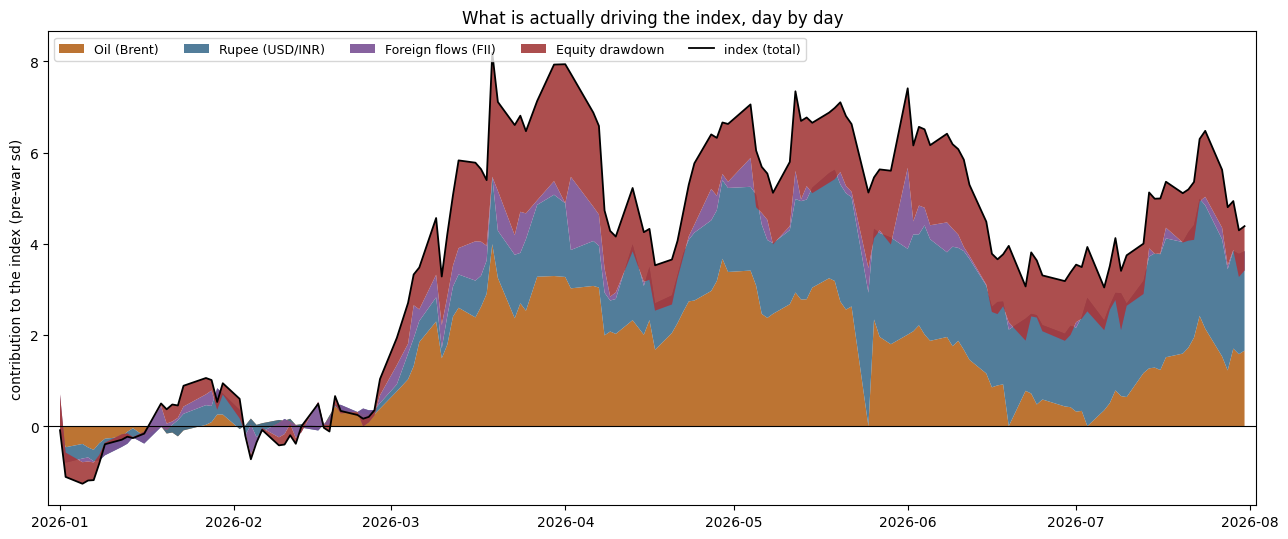

In [7]:
%matplotlib inline
# Decomposition: each channel's contribution to the index, stacked over time.
# Contribution = z / n_components (NOT z/4): on the 9 days where a channel is missing
# the index averages the ones present, so dividing by 4 would make the stack fall short
# of the line. This way the bands sum EXACTLY to the index on every single day.
fig, ax = plt.subplots(figsize=(13, 5.5))
contrib = si.set_index('date')[Z].div(si.set_index('date')['n_components'], axis=0).fillna(0)
cols = {'z_oil': '#b5651d', 'z_inr': '#3f6f8f', 'z_fii': '#7a5195', 'z_equity': '#a33b3b'}
ax.stackplot(contrib.index, *[contrib[c] for c in Z],
             labels=[NICE[c] for c in Z], colors=[cols[c] for c in Z], alpha=.9)
ax.plot(si.date, si.stress_index, color='k', lw=1.3, label='index (total)')
ax.axhline(0, color='k', lw=.8)
ax.set_ylabel('contribution to the index (pre-war sd)')
ax.set_title('What is actually driving the index, day by day')
ax.legend(loc='upper left', fontsize=9, ncol=5)
ax.margins(x=.01)
plt.tight_layout(); plt.show()

**How to read this chart:** each band is one channel's contribution to the composite (its z-score divided by the number of channels available that day); stacked, the bands sum **exactly** to the black index line. Band **thickness = how much that channel is contributing that day**.

Read left to right, the war has phases with different *drivers*, not just different intensities:

- **Late Feb – early Apr:** the orange oil band explodes and dominates — a pure supply shock.
- **Apr – mid Jun:** oil stays thick but the blue rupee band widens steadily beneath it — the shock has migrated into the currency and is becoming structural.
- **Mid Jun – early Jul:** oil collapses as the MoU lands, and the index falls almost entirely because of it — but the blue band does not shrink.
- **July onward:** oil thickens again on renewed conflict, on top of a rupee band that is now the largest single contributor.

The narrow one-day collapses in the orange band (late May, mid June, early July) are **not oil stress vanishing** — they are the documented missing-Brent days, where the band is genuinely absent and the remaining channels are divided by 3 instead of 4. The black line stays continuous through them because the index averages what is available.

The purple FII band is **visibly the thinnest throughout** — the graphical version of the 5.4% influence figure above. Note also that this decomposition is only possible because the z-scores are stored per-channel in `stress_components`: any index reading can be traced to the channels that produced it, which is what makes the index auditable rather than a black box.

### Finding

The India War Stress Index compresses four channels into one daily number that **calibrates to 0.01 over the pre-war baseline**, rises to **5.68 in acute war** and **5.91 under the naval blockade**, falls to **3.60 as the MoU de-escalation lands**, and climbs again to **4.83 in renewed conflict** — tracking the actual course of the war from a formula that never sees a war event. It passes both sanity checks the milestone requires: severity 4–5 events move it **+0.86 / +0.54** while severity-3 events move it **−0.17**, and it declines through de-escalation. Because severity was scored from event content blind to market reaction, that agreement is evidence rather than construction.

The construction also revealed two things worth more than the index itself:

1. **Equal weighting is nominal, not real.** Given 25% each, the channels actually contribute **39.6% oil / 28.7% rupee / 26.3% equity / 5.4% flows**. Z-scoring equalises units but not persistence: level channels that shift and stay shifted accumulate large permanent z-scores, while a mean-reverting daily flow does not. The FII channel — the project's headline story at ₹1.85 lakh crore of outflows — is reduced to a twentieth of the signal.
2. **The index measures cumulative displacement, not current intensity.** The rupee channel correlates **+0.93 with time**; USD/INR ratchets 90.7 → 96.1 and never returns, so the index never returns toward zero either. Economically honest (a permanently weaker rupee is permanent imported-inflation stress) but a materially different quantity from "how acute is the stress today", and it is why the blockade phase outranks the more damaging acute-war phase.

Both are properties of the specified construction, reported rather than silently corrected — the index above is exactly the one the milestone plan defines. **Carried into Component 3:** the historical benchmarking applies this same methodology to the Covid-2020 and 2022 energy shocks, each normalised on **its own** pre-shock baseline; the persistence effect above means "peak index" and "time to return toward baseline" must be compared with the trend caveat in view, since an episode whose currency move reverses will decay toward zero while one whose currency move sticks will not.